<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.5 MB/s eta 0:00:00


In [2]:
!pip install optuna

In [3]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.5 MB/s eta 0:00:00



--- [1. Optuna パラメータ最適化] ---

--- [2. 学習フェーズ開始 (Testデータは一切使用しません)] ---
>> Running Seed: 42...
[0]	validation_0-logloss:0.67214
[1]	validation_0-logloss:0.65449
[2]	validation_0-logloss:0.63840
[3]	validation_0-logloss:0.62406
[4]	validation_0-logloss:0.61016
[5]	validation_0-logloss:0.59937
[6]	validation_0-logloss:0.58756
[7]	validation_0-logloss:0.57864
[8]	validation_0-logloss:0.56905
[9]	validation_0-logloss:0.55942
[10]	validation_0-logloss:0.55131
[11]	validation_0-logloss:0.54271
[12]	validation_0-logloss:0.53371
[13]	validation_0-logloss:0.52455
[14]	validation_0-logloss:0.51668
[15]	validation_0-logloss:0.51015
[16]	validation_0-logloss:0.50577
[17]	validation_0-logloss:0.49833
[18]	validation_0-logloss:0.49191
[19]	validation_0-logloss:0.48676
[20]	validation_0-logloss:0.48207
[21]	validation_0-logloss:0.47700
[22]	validation_0-logloss:0.47167
[23]	validation_0-logloss:0.46907
[24]	validation_0-logloss:0.46467
[25]	validation_0-logloss:0.46078
[26]	validation_0-logloss:0.457

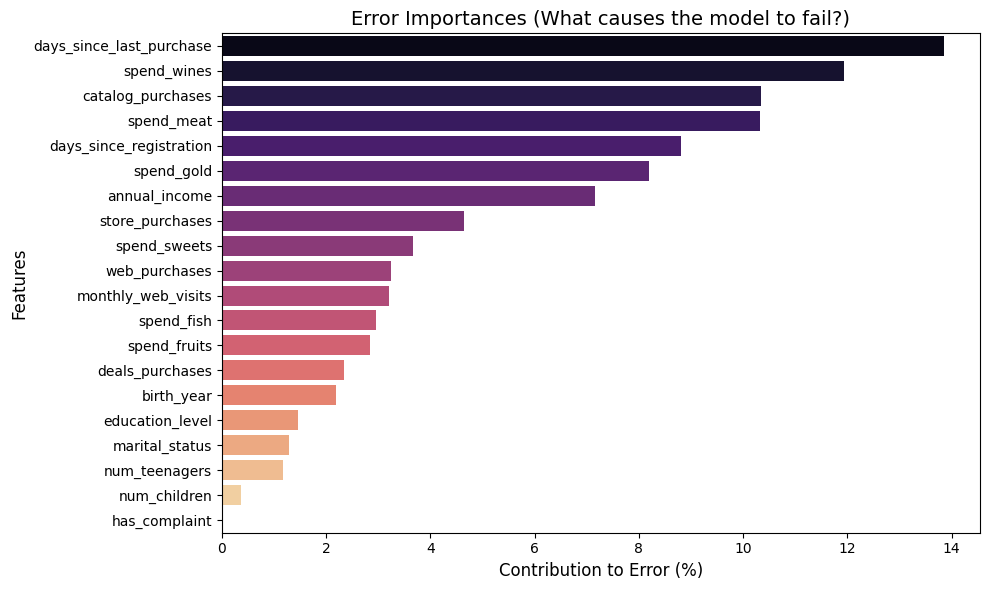


▼ AIがエラーを起こす条件ルール (is_error=1 になりやすい分岐):
|--- catalog_purchases <= 0.50
|   |--- monthly_web_visits <= 7.50
|   |   |--- days_since_registration <= 703.50
|   |   |   |--- class: 0
|   |   |--- days_since_registration >  703.50
|   |   |   |--- class: 0
|   |--- monthly_web_visits >  7.50
|   |   |--- days_since_last_purchase <= 19.50
|   |   |   |--- class: 1
|   |   |--- days_since_last_purchase >  19.50
|   |   |   |--- class: 0
|--- catalog_purchases >  0.50
|   |--- days_since_last_purchase <= 41.50
|   |   |--- annual_income <= 79492.50
|   |   |   |--- class: 1
|   |   |--- annual_income >  79492.50
|   |   |   |--- class: 1
|   |--- days_since_last_purchase >  41.50
|   |   |--- spend_wines <= 771.00
|   |   |   |--- class: 0
|   |   |--- spend_wines >  771.00
|   |   |   |--- class: 1



TypeError: plot_feature_importances() missing 1 required positional argument: 'feature_names'

In [6]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理（行単位の処理）
# ==========================================
def preprocess_safe_row_wise(df):
    """他行のデータに依存しない処理（日付計算など）は分割前に行ってOK"""
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')
    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)
    return df

# ==========================================
# 1. Optuna (パラメータチューニング)
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1. Optuna パラメータ最適化] ---")

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            # 簡易的な内部前処理
            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = LGBMClassifier(**params)

            # 【修正箇所】LightGBM標準の early_stopping を使用
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )

            oof[va_idx] = model.predict_proba(X_va)[:, 1]

        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_estimators': 1000, 'class_weight': 'balanced', 'verbose': -1})
    return best_params

# ==========================================
# 2. 学習フェーズ (Train & Validate)
# ==========================================
def train_models(X_raw, y, lgb_best_params, seeds=[42, 2023, 777], n_splits=5):
    """
    Testデータを一切見ずに、モデルの学習と検証のみを行う関数。
    後で予測に使うための「モデルと前処理ルールのセット（Artifacts）」を出力する。
    """
    print(f"\n--- [2. 学習フェーズ開始 (Testデータは一切使用しません)] ---")

    artifacts = [] # 学習済みのモデルと前処理ルールを保存するリスト
    oof_preds_ensemble = np.zeros(len(X_raw))
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            # 1. データ分割
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            # 2. 前処理ルールの「学習 (fit)」と「適用 (transform)」
            # 欠損値
            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

            # カテゴリ変数
            categorical_cols = ['education_level', 'marital_status']
            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = encoder.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            # 3. モデルの学習
            lgb_params = lgb_best_params.copy()
            lgb_params['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**lgb_params),
                'XGBoost': XGBClassifier(random_state=seed, n_estimators=1000, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio, early_stopping_rounds=50, eval_metric='logloss'),
                'RandomForest': RandomForestClassifier(random_state=seed, n_estimators=100, max_depth=10, class_weight='balanced')
            }

            fold_val_preds = np.zeros(len(X_va))
            for name, model in models.items():
                if name in ['LightGBM', 'XGBoost']:
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])
                else:
                    model.fit(X_tr, y_tr)

                fold_val_preds += model.predict_proba(X_va)[:, 1] / len(models)

            oof_seed[val_idx] = fold_val_preds

            # 4. 【重要】予測に使うための「成果物 (Artifact)」を保存
            artifacts.append({
                'seed': seed,
                'fold': fold,
                'preprocessors': {
                    'income_median': income_median,
                    'encoder': encoder,
                    'cat_cols': categorical_cols
                },
                'models': models,
                'feature_names': list(X_tr.columns)
            })

        oof_preds_ensemble += oof_seed / len(seeds)

    # =============== 追加・変更部分 ===============
    final_auc = roc_auc_score(y, oof_preds_ensemble)
    final_logloss = log_loss(y, oof_preds_ensemble)
    print(f"✅ 学習完了: 最終 OOF AUC: {final_auc:.4f} | 最終 Log Loss: {final_logloss:.4f}")
    # ============================================

    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ (Predict)
# ==========================================
def predict_models(X_test_raw, artifacts):
    """
    保存されたアーティファクト（前処理ルールとモデル）を読み込み、
    未知のデータに対して予測を行う関数。
    """
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0

    # 保存された各Foldの成果物を順番に取り出す
    for artifact in artifacts:
        X_te = X_test_raw.copy()
        preps = artifact['preprocessors']
        models = artifact['models']

        # 1. 【リーク防止】このFoldのTrainから作ったルールでテストデータを前処理
        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
        X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

        # 2. このFoldのモデルたちで予測
        for name, model in models.items():
            final_test_preds += model.predict_proba(X_te)[:, 1]
            total_models += 1

    # 全モデルの平均をとる
    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによるアンサンブル予測を実行しました。")
    return final_test_preds

# ==========================================
# 4. エラー分析 ＆ 損失原因度(Error Importance)のグラフ化
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [3. エラー分析 (損失原因の特定)] ---")

    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_prob'] = oof_preds
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)

    # 新しいターゲット：間違えたら1（エラー）、正解したら0
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)

    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    # --- 損失原因度モデルの学習 ---
    # エラーを予測するために、まずは簡易的に前処理（欠損値とカテゴリ処理）
    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())

    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    # エラー原因をあぶり出すため、少し深めのRandom Forestを使用
    error_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])

    # --- 損失原因度 (Error Importance) の算出とグラフ化 ---
    error_importance = pd.DataFrame({
        'Feature': X_error.columns,
        'Error_Importance': error_model.feature_importances_ * 100
    }).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)

    print("\n▼ 損失原因度ランキング トップ5 (モデルを騙している戦犯):")
    print(error_importance.head(5))

    # グラフの描画
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Error_Importance', y='Feature', data=error_importance, palette='magma')
    plt.title('Error Importances (What causes the model to fail?)', fontsize=14)
    plt.xlabel('Contribution to Error (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- ルールの言語化 (決定木) ---
    dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
    dt.fit(X_error, error_df['is_error'])
    print("\n▼ AIがエラーを起こす条件ルール (is_error=1 になりやすい分岐):")
    print(export_text(dt, feature_names=list(X_error.columns)))

    return error_importance

# ==========================================
# メイン実行ブロック (美しく分離されたフロー)
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    # ① データの準備
    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    # ② パラメータ最適化
    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)

    # ③ 【学習フェーズ】 モデルの訓練とアーティファクトの取得
    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params)

    # ④ 【予測フェーズ】 未知のデータをアーティファクトで推論
    final_predictions = predict_models(X_test_raw, artifacts)

    # ⑤ 分析・可視化
    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    # ⑥ 出力
    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_ultimate_submission_separated.csv', index=False)
    print("\n✅ 全工程完了: 'final_ultimate_submission_separated.csv' を出力しました！")